In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot
import pandas as pd
import numpy as np

import scipy
import awkward
import time
import subprocess

GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [63]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = "v39"

for data_year in ['all']:

    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == '2024':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2024-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['sig_15'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
fpath['sig_40'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-40-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
fpath['sig_55'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-55-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
# fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-55-ctauS-10000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v39/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 182909920.0
sig_15 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 189759580.0
sig_40 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized/ggH_Hto2Sto4B_MH-125-MS-40-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 195382980.0
sig_55 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized/ggH_Hto2Sto4B_MH-125-MS-55-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 195152240.0
CPU times: user 872 ms, sys: 39 ms, total: 911 ms
Wall time: 1.41 s


# apply selections

In [64]:
%%time

cscRechitClusterPhi = {}
cscRechitClusterSize = {}
dtRechitClusterPhi = {}
deltaPhi_cluster  = {}
cscRechitClusterDNN  = {}
dtRechitClusterSize  = {}
dtRechitClusterEta = {}
cscRechitClusterEta = {}
cscRechitClusterNStation = {}
cscRechitClusterMet_dPhi = {}
dtRechitClusterNStation = {}
dtRechitClusterBX  = {}
dtRechitClusterMet_dPhi = {}
deltaR_cluster = {}
deltaEta_cluster = {}
HMTEff = {}
weight = {}
runNum = {}
met = {}
dtRechitClusterMaxStation= {}
NStation = {}
dtRechitClusterOppSegSt1 = {}
dtRechitClusterOppSegSt2 = {}
dtRechitClusterOppSegSt3 = {}
dtRechitClusterOppSegSt4 = {}
            
dtRechitCluster_match_MB1hits_cosmics_plus = {}
dtRechitCluster_match_MB1hits_cosmics_minus = {}
# thresholds = {
# 'lowMET': [150,130,2.5],
# 'highMET': [100,180,2.5],}
# thresholds = {
# 'lowMET': [100,180,2.7],
# 'highMET': [110,170,2.0],}
thresholds = {
'lowMET': [100,190,2.7],
'highMET': [130,170,2.0],}
MET_THRESHOLD = 50
categories = ['lowMET','highMET']
# categories = ['lowMET']
region_list = ['invertDNN', 'oot', 'signal']
# region_list = ['signal']
for region in region_list:
    for tree_k in tree.keys():
        T = tree[tree_k]
        
        for met_cat in categories:
            # if not (met_cat == 'highMET'):continue
            k = f'{region}_{tree_k}_{met_cat}'
            ########### SELECTION: CLUSTERS ############
            me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
            T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())

            #one cluster to pass trigger
            csccluster = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            csccluster = csccluster & (me1 ==0)
            csccluster = csccluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<25)
            csccluster = csccluster & (np.abs(T['cscRechitClusterEta'].array())<1.9)
            csccluster = csccluster & (T['cscRechitClusterSize'].array()>thresholds[met_cat][0])
            csccluster = csccluster & (T['cscRechitClusterJetVetoPt'].array()<30)
            csccluster = csccluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > 30) & T['cscRechitClusterMuonVetoGlobal'].array())    


            dtcluster = (T['dtRechitCluster_match_RPChits_dPhi0p5'].array() >= 1)
            dtcluster = dtcluster & (T['dtRechitClusterJetVetoPt'].array()<30)
            dtcluster = dtcluster & np.logical_not((T['dtRechitClusterMuonVetoPt'].array() > 30) & T['dtRechitClusterMuonVetoLooseId'].array())

            ###cosmic veto for DT clusters###
            
            sel_cosmic = np.logical_and(T['dtRechitClusterNOppositeSegStation1'].array()>0, T['dtRechitClusterNOppositeSegStation2'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation3'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation4'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation1'].array()+T['dtRechitClusterNOppositeSegStation2'].array()+\
                                       T['dtRechitClusterNOppositeSegStation3'].array()+T['dtRechitClusterNOppositeSegStation4'].array()>=6)
            nstation = (T['dtRechitClusterNSegStation1'].array()>1)*1+(T['dtRechitClusterNSegStation2'].array()>1)*1\
            +(T['dtRechitClusterNSegStation3'].array()>1)*1+(T['dtRechitClusterNSegStation4'].array()>1)*1
            dtcluster = dtcluster & np.logical_not(np.logical_and(nstation>=3, sel_cosmic))
            

            
        ########### SELECTION: EVENTS ############
            sel_ev = (T['nCscRechitClusters_nocut'].array()==1) & (T['nDtRechitClusters_nocut'].array()==1)
            if "data" in k: sel_ev = sel_ev & T['HLT_CSCCSC'].array()
            cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
            sel_ev  = np.logical_and(sel_ev,np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT
                       
            if met_cat == 'lowMET':sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < MET_THRESHOLD)
            else: sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() > MET_THRESHOLD)
            sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < 200)
            sel_ev = np.logical_and(sel_ev ,T['Flag_all'].array())
            sel_ev = np.logical_and(sel_ev ,T['nCscRings'].array()+T['nDtRings'].array()<10)
            sel_ev  = sel_ev & (np.sum(dtcluster, axis = 1) == 1)
            sel_ev  = sel_ev & (np.sum(csccluster, axis = 1) == 1)
            
            sel_ev = np.logical_and(sel_ev ,T['jetVeto'].array())
            sel_ev = np.logical_and(sel_ev ,T['Flag_ecalBadCalibFilter'].array())
                
            print(k, np.count_nonzero(sel_ev))
            

        ########### BRANCHES ############

           ##### event variables ##### 
            # make sure cluster0 and cluster1 index are different

            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev][:,0]
            deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi[k]), np.array(dtRechitClusterPhi[k]))

            cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev][:,0]
            dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev][:,0]
            dtRechitClusterSize[k] = T['dtRechitClusterSize'].array()[dtcluster][sel_ev][:,0]

            if "lowMET" in k: sel = (np.abs(deltaPhi_cluster[k])>1)
            else: sel = (np.abs(deltaPhi_cluster[k])>0.4)
            sel = (np.abs(deltaPhi_cluster[k])>0.4)
            
            if 'oot' in region:sel = sel & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k]<0)
            elif 'invertDNN' in region: sel = sel & (cscRechitClusterDNN[k] < 0.96) & (dtRechitClusterBX[k] == 0)
            elif 'signal' in region:
                sel = sel & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k] == 0)
            else: assert(False)


            print(k, np.count_nonzero(sel))
            cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()[csccluster][sel_ev][sel][:,0]
            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterEta[k] = T['dtRechitClusterEta'].array()[dtcluster][sel_ev][sel][:,0]
            
            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev][sel][:,0]
            
            
            cscRechitClusterNStation[k] = T['cscRechitClusterNStation10'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterNStation[k] = T['dtRechitClusterNStation10'].array()[dtcluster][sel_ev][sel][:,0]
            cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitCluster_match_MB1hits_cosmics_plus[k] = T['dtRechitCluster_match_MB1hits_cosmics_plus'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitCluster_match_MB1hits_cosmics_minus[k] = T['dtRechitCluster_match_MB1hits_cosmics_minus'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterMaxStation[k] = T['dtRechitClusterMaxStation'].array()[dtcluster][sel_ev][sel][:,0]

            

        
            deltaPhi_cluster[k] = deltaPhi_cluster[k][sel]
            met[k] = T['met'].array()[sel_ev][sel]
            cscRechitClusterMet_dPhi[k] = T['cscRechitClusterMet_dPhi'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterMet_dPhi[k] = T['dtRechitClusterMet_dPhi'].array()[dtcluster][sel_ev][sel][:,0]
            runNum[k] = T['runNum'].array()[sel_ev][sel]
            deltaR_cluster[k] = ((cscRechitClusterEta[k]-dtRechitClusterEta[k])**2 + deltaPhi_cluster[k]**2)**0.5
            deltaEta_cluster[k] = cscRechitClusterEta[k]-dtRechitClusterEta[k]
            dtRechitClusterSize[k] = dtRechitClusterSize[k][sel]
            HMTEff[k] = T['cscRechitClusterHMTEfficiency'].array()[sel_ev][sel][:,0]
            weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev][sel]*HMTEff[k]
            if 'data' in k:weight[k] = T['weight'].array()[sel_ev][sel]*0.0 + 1
            print(k,len(weight[k]),np.sum(weight[k]))
            if np.count_nonzero(sel)<=1:continue
            print("correlation between two variables:", k, scipy.stats.pearsonr(deltaPhi_cluster[k], dtRechitClusterSize[k]))
            print("events in this region:", k, len(deltaPhi_cluster[k]))

invertDNN_dataall_lowMET 780603
invertDNN_dataall_lowMET 79784
invertDNN_dataall_lowMET 79784 79784.0
correlation between two variables: invertDNN_dataall_lowMET (-0.0009783495154350318, 0.7822862109759031)
events in this region: invertDNN_dataall_lowMET 79784
invertDNN_dataall_highMET 74273
invertDNN_dataall_highMET 9873
invertDNN_dataall_highMET 9873 9873.0
correlation between two variables: invertDNN_dataall_highMET (0.007307513317403831, 0.46783019345505844)
events in this region: invertDNN_dataall_highMET 9873
invertDNN_sig_15_lowMET 22107
invertDNN_sig_15_lowMET 2042
invertDNN_sig_15_lowMET 2042 1465.7174
correlation between two variables: invertDNN_sig_15_lowMET (0.0035201988398527416, 0.8736881180301734)
events in this region: invertDNN_sig_15_lowMET 2042
invertDNN_sig_15_highMET 10459
invertDNN_sig_15_highMET 943
invertDNN_sig_15_highMET 943 720.8261
correlation between two variables: invertDNN_sig_15_highMET (-0.02781051726840415, 0.39363373595968515)
events in this region: i

In [32]:
dtRechitClusterBX['oot_dataall_lowMET']

<Array [-1, -1, -1, -2, -2, ... -1, -2, -1, -1] type='63572 * int32'>

In [ ]:
v22

invertDNN_dataall_lowMET 821.0
invertDNN_dataall_highMET 125.0
oot_dataall_lowMET 637.0
oot_dataall_highMET 105.0
signal_dataall_lowMET 917.0
signal_dataall_highMET 85.0


old

invertDNN_dataall_lowMET 605.0
invertDNN_dataall_highMET 1179.0
invertDNN_sig_lowMET 0.86407954
invertDNN_sig_highMET 14.806614
oot_dataall_lowMET 490.0
oot_dataall_highMET 823.0
oot_sig_lowMET 0.0
oot_sig_highMET 0.2234029
signal_dataall_lowMET 689.0
signal_dataall_highMET 827.0
signal_sig_lowMET 16.188862
signal_sig_highMET 98.821205

150 4 28
150 0.125
160 3 22
160 0.12
170 1 16
170 0.058823529411764705
180 0 14
180 0.0
190 0 9
190 0.0
0.023090600967407227


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


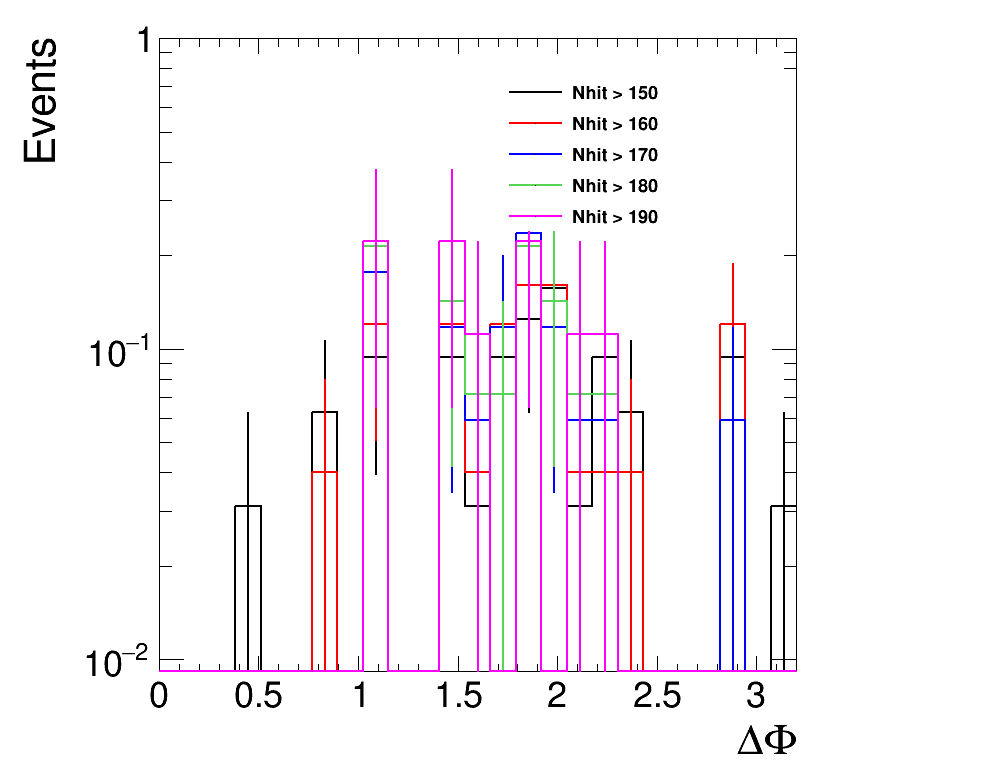

In [53]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
plot_var = [cscRechitClusterMet_dPhi, dtRechitClusterMet_dPhi, runNum,dtRechitClusterSize, deltaPhi_cluster, cscRechitClusterEta,cscRechitClusterSize,cscRechitClusterNStation, dtRechitClusterNStation, cscRechitClusterDNN, deltaR_cluster, met, cscRechitClusterPhi, dtRechitClusterPhi]
axis = ['cscRechitClusterMet_dPhi', 'dtRechitClusterMet_dPhi', "runNum", 'N_{dt rechits}','#Delta#phi','csc cluster #eta','N_{csc rechits}', 'csc cluster N_{station 10}', 'dt cluster N_{station 10}', 'cscRechitClusterDNN','deltaR', 'met', 'cscRechitClusterPhi','dtRechitClusterPhi']
name = ['cscRechitClusterMet_dPhi', 'dtRechitClusterMet_dPhi','nhits','dphi','cscRechitClusterEta','cscRechitClusterSize','cscRechitClusterNStation10', 'dtRechitClusterNStation10', 'cscRechitClusterDNN','deltaR_cluster','met', 'cscRechitClusterPhi', 'dtRechitClusterPhi']
bins = [[25,0,3.2],[25,0,3.2],[1000, 360019, 387121],[25,0,500],[25,0,3.2],[50,1,2.5],[50,0,800],[5,0,5], [5,0,5], [50,0.5,1], [50,0,4],[50,0,200], [50,-4,4], [50,-4,4]]

plot_index = 0
i = 0
k = 'oot_dataall_highMET'
DPHI_CUT =2.5
nhit = 50
for nhit_threshold in np.arange(150,200,10):
    # cond = (np.abs(deltaPhi_cluster[k])>1) & (cscRechitClusterDNN[k]>0.9)
    cond = (np.abs(deltaPhi_cluster[k])>=0) 
    # cond = cond & (dtRechitClusterSize[k]>=nhit) & (dtRechitClusterSize[k]<nhit_threshold)
    cond = cond & (dtRechitClusterSize[k]>=nhit_threshold)
    h[nhit_threshold] = create_TH1D( np.abs(np.array(deltaPhi_cluster[k][cond])), axis_title = ["#Delta#Phi",'Events'], binning=[25,0,3.2], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterEta[k][cond]), axis_title = ["#Delta#eta",'Events'], binning=[25,-1,1], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterBX[k][cond]), axis_title = ["#Delta#Phi",'Events'], binning=[20,-10,10], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterMaxStation[k][cond]), axis_title = ["#Delta#Phi",'Events'], binning=[10,-5,5], weights = np.array(weight[k][cond]))
    if h[nhit_threshold].Integral()>0: h[nhit_threshold].Scale(1./h[nhit_threshold].Integral())
    h[nhit_threshold].SetLineColor(std_color_list[i])
    h[nhit_threshold].SetMaximum(1)
    print(nhit_threshold, np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))>=DPHI_CUT), np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))<DPHI_CUT))
    print(nhit_threshold, np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))>=DPHI_CUT)/np.count_nonzero(cond))
    leg.AddEntry(h[nhit_threshold],f"Nhit > {nhit_threshold}")
    h[nhit_threshold].Draw('histE same')
    i+=1
    # nhit = nhit_threshold

    
leg.Draw()
if plot_index == 0 or plot_index == 3 or plot_index == 8:c.SetLogy()
c.SetRightMargin(0.2)
# c.SetLogy()
c.Draw()

print(time.time()-start_t)

# Plot 1D distributions

invertDNN_dataall_highMET 0.0
oot_dataall_highMET 0.0
signal_dataall_highMET 0.0
signal_sig_15_highMET 0.0
signal_sig_40_highMET 0.0
signal_sig_55_highMET 0.0
0.10513854026794434


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/l

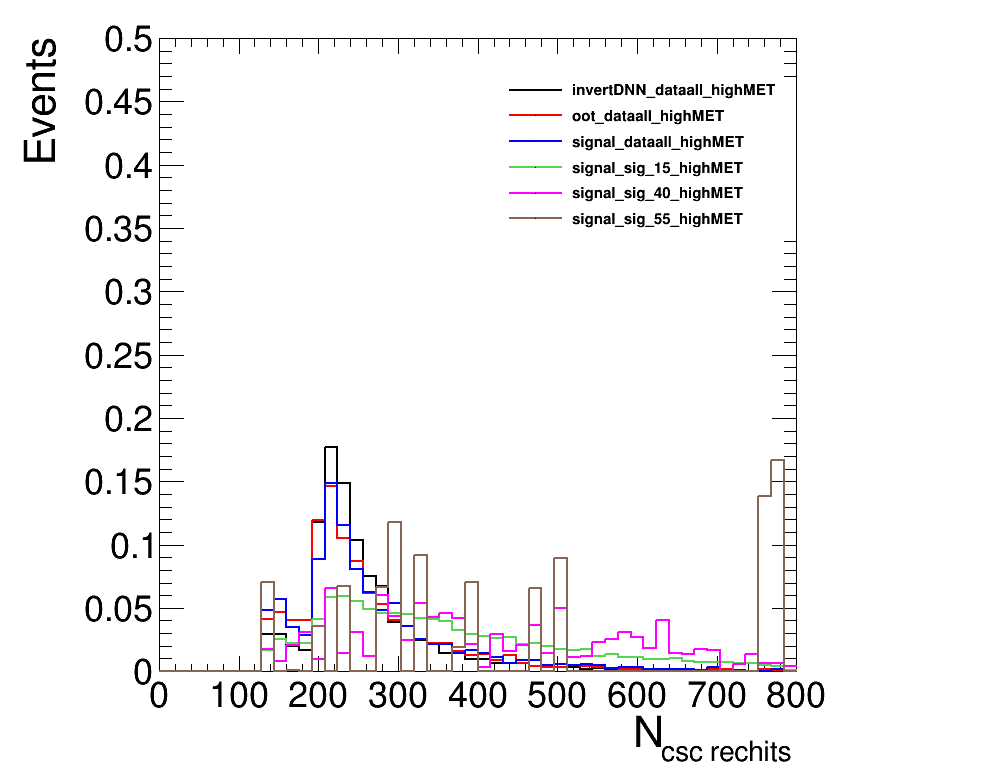

In [79]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
plot_var = [cscRechitClusterMet_dPhi, dtRechitClusterMet_dPhi, runNum,dtRechitClusterSize, deltaPhi_cluster, cscRechitClusterEta,cscRechitClusterSize,cscRechitClusterNStation, dtRechitClusterNStation, cscRechitClusterDNN, deltaR_cluster, met, cscRechitClusterPhi, dtRechitClusterPhi]
axis = ['cscRechitClusterMet_dPhi', 'dtRechitClusterMet_dPhi',"runNum", 'N_{dt rechits}','#Delta#phi','csc cluster #eta','N_{csc rechits}', 'csc cluster N_{station 10}', 'dt cluster N_{station 10}', 'cscRechitClusterDNN','deltaR', 'met', 'cscRechitClusterPhi','dtRechitClusterPhi']
name = ['cscRechitClusterMet_dPhi', 'dtRechitClusterMet_dPhi','nhits','dphi','cscRechitClusterEta','cscRechitClusterSize','cscRechitClusterNStation10', 'dtRechitClusterNStation10', 'cscRechitClusterDNN','deltaR_cluster','met', 'cscRechitClusterPhi', 'dtRechitClusterPhi']
bins = [[25,0,3.2],[25,0,3.2], [1000, 360019, 387121],[25,0,500],[25,0,3.2],[50,1,2.5],[50,0,800],[5,0,5], [5,0,5], [50,0.5,1], [50,0,4],[50,0,200], [50,-4,4], [50,-4,4]]

                               
plot_index = 6
i = 0
for k in plot_var[plot_index].keys():

    # if 'signal_dataall' in k:continue
    if not "high" in k:continue
    # if "
    # if not "OOT" in k and  not "signal" in k:continue
    if 'invertDNN_sig' in k or 'oot_sig' in k:continue
    # if not "signal_si" in k:continue
    # if not "oot_dataall_lowMET" in k:continue
    cond = cscRechitClusterSize[k]>0
    cond = cond & (np.abs(deltaPhi_cluster[k])>2)
    h[k] = create_TH1D( np.abs(np.array(plot_var[plot_index][k][cond])), axis_title = [axis[plot_index],'Events'], binning=bins[plot_index], weights = np.array(weight[k][cond]))
    h[k] = create_TH1D( np.array(plot_var[plot_index][k][cond]), axis_title = [axis[plot_index],'Events'], binning=bins[plot_index], weights = np.array(weight[k][cond]))
    if np.count_nonzero(cond)>0:print(k, np.count_nonzero(np.array(plot_var[plot_index][k][cond])<1.9)/np.count_nonzero(cond))
    if h[k].Integral()>0:h[k].Scale(1./h[k].Integral())
    h[k].SetLineColor(std_color_list[i])
    h[k].SetMaximum(0.5)
    # if "signal_data" in k:leg.AddEntry(h[k],'SR_data (region C)_' + k.split('_')[-1])
    # else:     leg.AddEntry(h[k],k.replace('all','').replace('_lowMET',''))

    leg.AddEntry(h[k],k)
    h[k].Draw('hist same')
    i+=1

    
leg.Draw()
if plot_index == 0 or plot_index == 3 or plot_index == 8:c.SetLogy()
c.SetRightMargin(0.2)
# c.SetLogy()
c.Draw()

c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.png")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.pdf")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.C")


print(time.time()-start_t)

# 2D distribution of dphi and Nrechits

invertDNN_dataall_lowMET 29998.0
invertDNN_dataall_highMET 5972.0
oot_dataall_lowMET 22767.0
oot_dataall_highMET 3945.0
oot_dataall_highMET 6545.0 6545
signal_dataall_lowMET 20896.0
signal_dataall_highMET 3982.0
0.01339578628540039


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


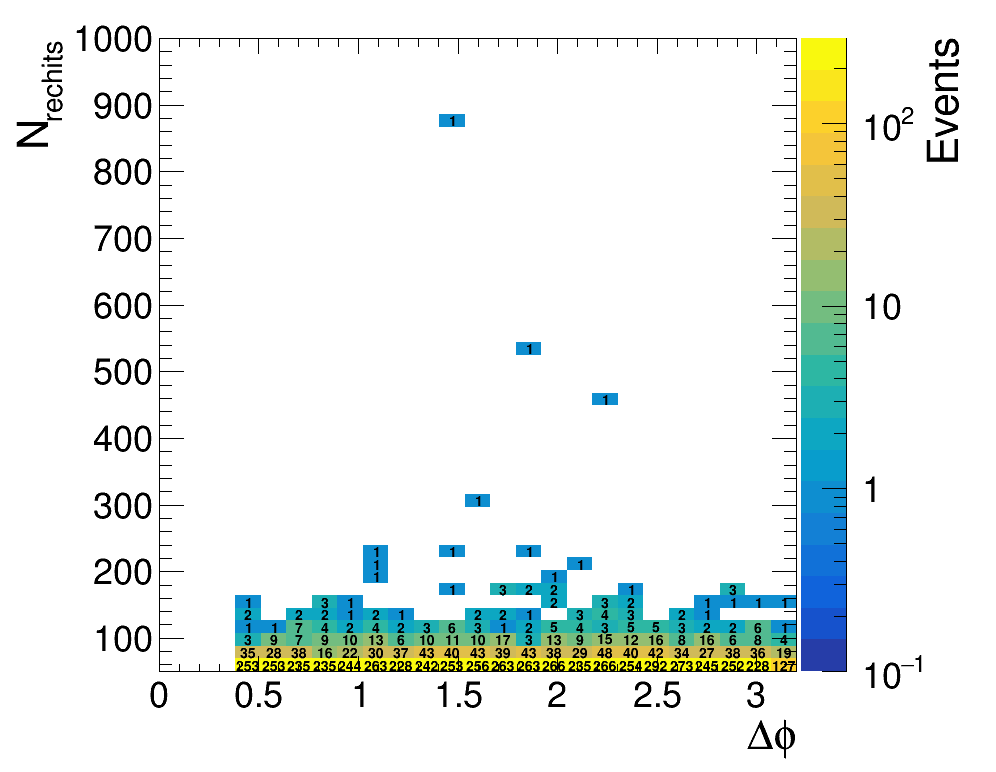

In [51]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)

for k in dtRechitClusterSize.keys():
    print(k, np.sum(weight[k][met[k]>50]))
    if not k == "oot_dataall_highMET":continue
    # if not k == "signal_dataall_highMET":continue
    cond = (np.abs(deltaPhi_cluster[k]) > 0)
    if "oot " in k: cond = cond & (dtRechitClusterBX[k]==-2) & (dtRechitClusterSize[k]>100)
    h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k][cond]), np.array(dtRechitClusterSize[k][cond]), )),
                   axis_title = ['#Delta#phi','N_{rechits}','Events'], binning=[25,0,3.2,50,50,1000,])
    # h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k][cond]), np.array(deltaEta_cluster[k][cond]))),
                   # axis_title = ['#Delta#phi','#Delta#eta','Events'], binning=[25,0,3.2,50,-5,5,])
    
    # h = create_TH2D(np.column_stack(( np.array(dtRechitClusterEta[k]), np.array(dtRechitClusterPhi[k]), )),
    #                axis_title = ['DT cluster #eta', 'DT cluster #phi','Events'], binning=[25,-1.1,1.1,25,-3.2,3.2,])
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta[k]), np.array(cscRechitClusterPhi[k]), )),
                   # axis_title = ['CSC cluster #eta', 'CSC cluster #phi','Events'], binning=[80,-2.5,2.5,25,-3.2,3.2,])
    # h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k]), np.array(met[k]), )),
    #                axis_title = ['#Delta#phi','met','Events'], binning=[25,0,3.2,50,0,500,])

    h.SetMinimum(0.1)
    h.Draw('colz text')
    c.SetRightMargin(0.2)

    print(k, h.Integral(), len(dtRechitClusterSize[k]))
    # if setlog: 
    c.SetLogz()
    c.Draw('')

#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".png")
#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".pdf")
#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".C")
    



print(time.time()-start_t)

In [70]:
k = "oot_dataall_highMET"
cond = (dtRechitClusterSize[k]>200)
for i in range(np.count_nonzero(cond)):
    print(dtRechitClusterBX[k][cond][i], deltaPhi_cluster[k][cond][i],dtRechitClusterSize[k][cond][i], \
         cscRechitClusterMet_dPhi[k][cond][i], dtRechitClusterMet_dPhi[k][cond][i])

-1 1.874793 232 -1.2785422801971436 3.129849910736084
-1 -2.1440308 208 0.08569341152906418 2.229724168777466
-1 1.914813 539 1.9302597045898438 0.015446662902832031
-1 -2.1934211 451 -0.7270423173904419 1.4663788080215454
-2 1.5315127 872 2.5243923664093018 0.9928796887397766
-1 -1.1415615 215 2.69686222076416 -2.4447615146636963
-1 1.0502769 223 2.0025269985198975 0.9522501230239868
-2 1.4786409 238 -0.5623368620872498 -2.040977716445923
-1 -1.5779529 307 -1.2667438983917236 0.31120890378952026


# ABCD (Scan Nrechits)

In [76]:
a = {}
b = {}
c = {}
d = {}
cuts = np.arange(50,106,1)
# cuts = np.arange(60,300,10)

cuts = np.arange(90,150,10)
n_ev = 5000

table = {}
latex_table = {}

# cuts = [90,95,100,104,105]
print(cuts)
bkg_dphiJet = []
sig_dphiJet = []
bkg_dphiCluster = []
sig_dphiCluster = []
print_jetmet = 0

for k in dtRechitClusterSize.keys():
    if 'sig_' in k:continue
    print("*****************************")
    print(f"******** {k} **********")
    print("*****************************")
    table[k] = {
        # "dPhi cuts": ['dphi', 'A', 'B', 'C', 'D', 'prediction', 'uncertainty'],
        "Nhits cuts":[],
        "A": [],
        "B": [],
        "C": [],
        "D": [],
        "pred":[],
        "uncertainty":[],
    }
    if "lowMET" in k: 
        DPHI_CUT = thresholds["lowMET"][-1]
        cuts =  [thresholds["lowMET"][1]]
    else: 
        DPHI_CUT = thresholds["highMET"][-1]
        cuts = [thresholds["highMET"][1]]
    # cuts = [150,170,190,200,210]
    print(f"DPHI_CUT:{DPHI_CUT}")
    print(cuts)
    for N_RECHIT_CUT in cuts:
        if N_RECHIT_CUT<80:continue
        
        cond = (cscRechitClusterDNN[k]>=0.9) 
        if "lowMET" in k: cond = cond & (np.abs(deltaPhi_cluster[k]) > 1.3)
        else:cond = cond & (np.abs(deltaPhi_cluster[k]) > 1.3)
        if 'oot' in k: cond = cond & (dtRechitClusterBX[k] == -2)
        var = np.abs(deltaPhi_cluster[k])
        
        a[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var>=DPHI_CUT)])
        b[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var<DPHI_CUT)])
        c[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var<DPHI_CUT)])
        d[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var>=DPHI_CUT)])

        if b[k] == 0 or c[k] == 0 or d[k] ==0:break
        pred = b[k]*d[k]/c[k]
        unc_pred = (1./c[k] + 1./b[k] + 1./d[k])**0.5*pred
        if math.isnan(unc_pred): z_value = float("nan")
        else:
            mu = np.random.normal(pred, unc_pred, n_ev)
            p_value = 0.0
            for i in mu:
                if i < 0:continue
                n = np.random.poisson(i, n_ev)
                p_value += np.count_nonzero(n>=a[k])

            p_value = p_value/n_ev**2
            z_value = abs(norm.ppf(p_value))
        print(N_RECHIT_CUT, '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
              round( unc_pred, 2), '\t', round(z_value,2))
        
        
        table[k]['Nhits cuts'].append(N_RECHIT_CUT)
        table[k]['A'].append(a[k])
        table[k]['B'].append(b[k])
        table[k]['C'].append(c[k])
        table[k]['D'].append(d[k])
        table[k]['pred'].append(pred)
        table[k]['uncertainty'].append(unc_pred)
        
        
    # write to latex format for AN
    table[k] = pd.DataFrame(table[k])
    latex_table[k] = table[k].to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="|l|l|l|l|l|",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
    )
    print(latex_table[k])


[ 90 100 110 120 130 140]
*****************************
******** invertDNN_dataall_lowMET **********
*****************************
DPHI_CUT:2.7
[190]
190 	 5 	 20 	 22376 	 7481 	 6.69 	 1.5 	 0.69
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &   B &      C &     D &  pred &  uncertainty \\
\midrule
        190 &  5 &  20 &  22376 &  7481 &  6.69 &         1.50 \\
\bottomrule
\end{tabular}

*****************************
******** invertDNN_dataall_highMET **********
*****************************
DPHI_CUT:2.0
[170]
170 	 3 	 3 	 1483 	 2548 	 5.15 	 2.98 	 0.67
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &  B &     C &     D &  pred &  uncertainty \\
\midrule
        170 &  3 &  3 &  1483 &  2548 &  5.15 &         2.98 \\
\bottomrule
\end{tabular}

*****************************
******** oot_dataall_lowMET **********
*****************************
DPHI_CUT:2.7
[190]
190 	 3 	 15 	 11680 	 3622 	 4.65 	 1.2 	 0.83
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &

In [77]:
VR_keys = [x.replace("_dataall_", " ") for x in table.keys()]
VR_keys = [x.replace("invert", "inverted ") for x in VR_keys]
VR_keys = [x.replace("lowMET", "low MET bin (MET $< $50 \GeV)") for x in VR_keys]
VR_keys = [x.replace("highMET", "high MET bin (MET $\geq$50 \GeV)") for x in VR_keys]
VR_keys = [x.replace("oot", " OOT") for x in VR_keys]

print(VR_keys)
all_table = pd.concat(table.values(), keys=VR_keys)
all_table =all_table.reset_index()
all_table = all_table[["level_0", "A", "B","C","D", "pred", "uncertainty"]]
print(all_table.head())
all_table = all_table.to_latex(
    header = ["validation region", "A", "B","C","D", "prediction", "uncertainty"],
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="l|l|l|l|l|l|l",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format,  # Formats floats to two decimal places
    caption = "Validation of the background estimation method for low MET DT-CSC category.\
    The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.",
    label = "tab:validation_lowMET_DTCSC",
    )
print(all_table.replace("midrule","hline"))

['inverted DNN low MET bin (MET $< $50 \\GeV)', 'inverted DNN high MET bin (MET $\\geq$50 \\GeV)', ' OOT low MET bin (MET $< $50 \\GeV)', ' OOT high MET bin (MET $\\geq$50 \\GeV)', 'signal low MET bin (MET $< $50 \\GeV)', 'signal high MET bin (MET $\\geq$50 \\GeV)']
                                         level_0   A   B      C     D  \
0     inverted DNN low MET bin (MET $< $50 \GeV)   5  20  22376  7481   
1  inverted DNN high MET bin (MET $\geq$50 \GeV)   3   3   1483  2548   
2              OOT low MET bin (MET $< $50 \GeV)   3  15  11680  3622   
3           OOT high MET bin (MET $\geq$50 \GeV)   0   3    646  1008   
4           signal low MET bin (MET $< $50 \GeV)  21  76  29590  8645   

        pred  uncertainty  
0   6.686629     1.497840  
1   5.154417     2.980662  
2   4.651541     1.204276  
3   4.681115     2.712920  
4  22.204123     2.561413  
\begin{table}
\centering
\caption{Validation of the background estimation method for low MET DT-CSC category.    The uncertain

In [ ]:
\begin{table}
\centering
\caption{Validation of the background estimation method for low MET DT-CSC category.    The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.}
\label{tab:validation_lowMET_DTCSC}
\begin{tabular}{l|l|l|l|l|l|l}
\toprule
                             validation region &  A &   B &    C &   D & prediction & uncertainty \\
\hline
    inverted DNN low MET bin (MET $< $50 \GeV) &  2 &   6 &  229 &  47 &       1.23 &        0.54 \\
 inverted DNN high MET bin (MET $\geq$50 \GeV) &  1 &   3 &   41 &  18 &       1.32 &        0.85 \\
             OOT low MET bin (MET $< $50 \GeV) &  2 &  15 &  405 &  97 &       3.59 &        1.01 \\
          OOT high MET bin (MET $\geq$50 \GeV) &  2 &   1 &   56 &  46 &       0.82 &        0.84 \\
\bottomrule
\end{tabular}
\end{table}


# ABCD (Scan dPhi)

In [5]:

a = {}
b = {}
c = {}
d = {}
cuts = np.arange(50,106,1)
cuts = np.arange(0,35,2)/10
cuts = np.arange(1.8,3.2,0.05)
print(cuts)
n_ev = 1000


table = {}
latex_table = {}

N_RECHIT_CUT = 90
for k in dtRechitClusterSize.keys():
    if 'sig' in k:continue
    
    table[k] = {
        # "dPhi cuts": ['dphi', 'A', 'B', 'C', 'D', 'prediction', 'uncertainty'],
        "dPhi cuts":[],
        "A": [],
        "B": [],
        "C": [],
        "D": [],
        "pred":[],
        "uncertainty":[],
    }
    print("*****************************")
    print(f"******** {k} **********")
    print("*****************************")
    for DPHI_CUT in cuts:
        var = np.abs(deltaPhi_cluster[k])
        
        a[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var>=DPHI_CUT)])
        b[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var<DPHI_CUT)])
        c[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var<DPHI_CUT)])
        d[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var>=DPHI_CUT)])


        if b[k] == 0 or c[k] == 0 or d[k] ==0:continue
        pred = b[k]*d[k]/c[k]
        unc_pred = (1./c[k] + 1./b[k] + 1./d[k])**0.5*pred
        if math.isnan(unc_pred): z_value = float("nan")
        else:
            mu = np.random.normal(pred, unc_pred, n_ev)
            p_value = 0.0
            for i in mu:
                if i < 0:continue
                n = np.random.poisson(i, n_ev)
                p_value += np.count_nonzero(n>=a[k])

            p_value = p_value/n_ev**2
            z_value = abs(norm.ppf(p_value))
        print(round(DPHI_CUT,2), '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
              round( unc_pred, 2), '\t', round(z_value,2))
        # table[k][DPHI_CUT] = [DPHI_CUT, int(a[k]),b[k],c[k],d[k],pred,unc_pred]

        
        table[k]['dPhi cuts'].append(DPHI_CUT)
        table[k]['A'].append(a[k])
        table[k]['B'].append(b[k])
        table[k]['C'].append(c[k])
        table[k]['D'].append(d[k])
        table[k]['pred'].append(pred)
        table[k]['uncertainty'].append(unc_pred)
        
        
        
    table[k] = pd.DataFrame(table[k])
    latex_table[k] = table[k].to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="|l|l|l|l|l|",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
    )

    print(latex_table[k])


[1.8  1.85 1.9  1.95 2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45
 2.5  2.55 2.6  2.65 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15]
*****************************
******** invertDNN_dataall_lowMET **********
*****************************
1.8 	 80 	 154 	 575 	 485 	 129.9 	 13.18 	 3.14
1.85 	 75 	 159 	 596 	 464 	 123.79 	 12.45 	 3.19
1.9 	 71 	 163 	 618 	 442 	 116.58 	 11.67 	 3.22
1.95 	 68 	 166 	 639 	 421 	 109.37 	 10.92 	 3.01
2.0 	 63 	 171 	 656 	 404 	 105.31 	 10.45 	 3.32
2.05 	 61 	 173 	 667 	 393 	 101.93 	 10.1 	 3.13
2.1 	 55 	 179 	 691 	 369 	 95.59 	 9.44 	 3.21
2.15 	 51 	 183 	 709 	 351 	 90.6 	 8.93 	 3.38
2.2 	 50 	 184 	 728 	 332 	 83.91 	 8.32 	 2.97
2.25 	 46 	 188 	 746 	 314 	 79.13 	 7.85 	 3.11
2.3 	 44 	 190 	 761 	 299 	 74.65 	 7.44 	 3.05
2.35 	 41 	 193 	 778 	 282 	 69.96 	 7.0 	 2.91
2.4 	 41 	 193 	 796 	 264 	 64.01 	 6.47 	 2.49
2.45 	 38 	 196 	 813 	 247 	 59.55 	 6.07 	 2.36
2.5 	 35 	 199 	 827 	 233 	 56.07 	 5.75 	 2.47
2.